In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

def bootstrap_grain_analysis(data, n_bootstrap=1000, sample_fractions=[0.1, 0.25, 0.5, 0.75, 1.0]):
    """
    Perform bootstrapping analysis on grain size data

    Parameters:
    - data: pandas Series of grain size measurements
    - n_bootstrap: number of bootstrap samples
    - sample_fractions: fractions of original dataset to test

    Returns:
    - Dictionary with bootstrap results
    """

    clean_data = data.dropna()
    n_total = len(clean_data)

    results = {}

    print(f"Bootstrap Analysis for {n_total} grains")
    print("="*50)

    for fraction in sample_fractions:
        sample_size = int(n_total * fraction)

        if sample_size < 10:  # Skip very small samples
            continue

        # Storage for bootstrap statistics
        bootstrap_means = []
        bootstrap_stds = []
        bootstrap_D16 = []
        bootstrap_D50 = []
        bootstrap_D84 = []

        # Perform bootstrap sampling
        for i in range(n_bootstrap):
            # Random sample with replacement
            bootstrap_sample = np.random.choice(clean_data, size=sample_size, replace=True)

            # Calculate statistics
            bootstrap_means.append(np.mean(bootstrap_sample))
            bootstrap_stds.append(np.std(bootstrap_sample))
            bootstrap_D16.append(np.percentile(bootstrap_sample, 16))
            bootstrap_D50.append(np.percentile(bootstrap_sample, 50))
            bootstrap_D84.append(np.percentile(bootstrap_sample, 84))

        # Calculate confidence intervals
        confidence_level = 95
        alpha = (100 - confidence_level) / 2

        results[fraction] = {
            'sample_size': sample_size,
            'mean': {
                'values': bootstrap_means,
                'mean': np.mean(bootstrap_means),
                'ci_lower': np.percentile(bootstrap_means, alpha),
                'ci_upper': np.percentile(bootstrap_means, 100-alpha)
            },
            'std': {
                'values': bootstrap_stds,
                'mean': np.mean(bootstrap_stds),
                'ci_lower': np.percentile(bootstrap_stds, alpha),
                'ci_upper': np.percentile(bootstrap_stds, 100-alpha)
            },
            'D16': {
                'values': bootstrap_D16,
                'mean': np.mean(bootstrap_D16),
                'ci_lower': np.percentile(bootstrap_D16, alpha),
                'ci_upper': np.percentile(bootstrap_D16, 100-alpha)
            },
            'D50': {
                'values': bootstrap_D50,
                'mean': np.mean(bootstrap_D50),
                'ci_lower': np.percentile(bootstrap_D50, alpha),
                'ci_upper': np.percentile(bootstrap_D50, 100-alpha)
            },
            'D84': {
                'values': bootstrap_D84,
                'mean': np.mean(bootstrap_D84),
                'ci_lower': np.percentile(bootstrap_D84, alpha),
                'ci_upper': np.percentile(bootstrap_D84, 100-alpha)
            }
        }

        print(f"Sample fraction {fraction:.1%} (n={sample_size}):")
        print(f"  D50: {results[fraction]['D50']['mean']:.3f} "
              f"({results[fraction]['D50']['ci_lower']:.3f}-{results[fraction]['D50']['ci_upper']:.3f})")

    return results

# Apply to your datasets
print("BOOTSTRAPPING ANALYSIS FOR CAMERA VS UPLOAD COMPARISON")
print("="*70)
print(f"Analysis Date: 2025-08-08 20:15:08 UTC")
print(f"User: esemsc-mcu24")
print("="*70)

# Clean your data
df_camera = pd.read_csv('/content/camera_grain_analysis_20250801_114733.csv')
df_upload = pd.read_csv('/content/grain_analysis_20250807_13331933.csv')
camera_major = df_camera['major_axis_length'].dropna()
camera_minor = df_camera['minor_axis_length'].dropna()
upload_major = df_upload['major_axis_length'].dropna()
upload_minor = df_upload['minor_axis_length'].dropna()

# Perform bootstrap analysis for all datasets
datasets = {
    'Camera Major': camera_major,
    'Camera Minor': camera_minor,
    'Upload Major': upload_major,
    'Upload Minor': upload_minor
}

bootstrap_results = {}
for name, data in datasets.items():
    print(f"\n🔄 BOOTSTRAPPING: {name}")
    bootstrap_results[name] = bootstrap_grain_analysis(data, n_bootstrap=1000)

BOOTSTRAPPING ANALYSIS FOR CAMERA VS UPLOAD COMPARISON
Analysis Date: 2025-08-08 20:15:08 UTC
User: esemsc-mcu24

🔄 BOOTSTRAPPING: Camera Major
Bootstrap Analysis for 257 grains
Sample fraction 10.0% (n=25):
  D50: 1.203 (1.033-1.390)
Sample fraction 25.0% (n=64):
  D50: 1.202 (1.085-1.330)
Sample fraction 50.0% (n=128):
  D50: 1.200 (1.113-1.293)
Sample fraction 75.0% (n=192):
  D50: 1.199 (1.128-1.278)
Sample fraction 100.0% (n=257):
  D50: 1.200 (1.135-1.269)

🔄 BOOTSTRAPPING: Camera Minor
Bootstrap Analysis for 257 grains
Sample fraction 10.0% (n=25):
  D50: 0.755 (0.655-0.874)
Sample fraction 25.0% (n=64):
  D50: 0.757 (0.684-0.827)
Sample fraction 50.0% (n=128):
  D50: 0.760 (0.709-0.805)
Sample fraction 75.0% (n=192):
  D50: 0.760 (0.716-0.791)
Sample fraction 100.0% (n=257):
  D50: 0.760 (0.719-0.789)

🔄 BOOTSTRAPPING: Upload Major
Bootstrap Analysis for 419 grains
Sample fraction 10.0% (n=41):
  D50: 2.346 (2.019-2.722)
Sample fraction 25.0% (n=104):
  D50: 2.338 (2.134-2.565)

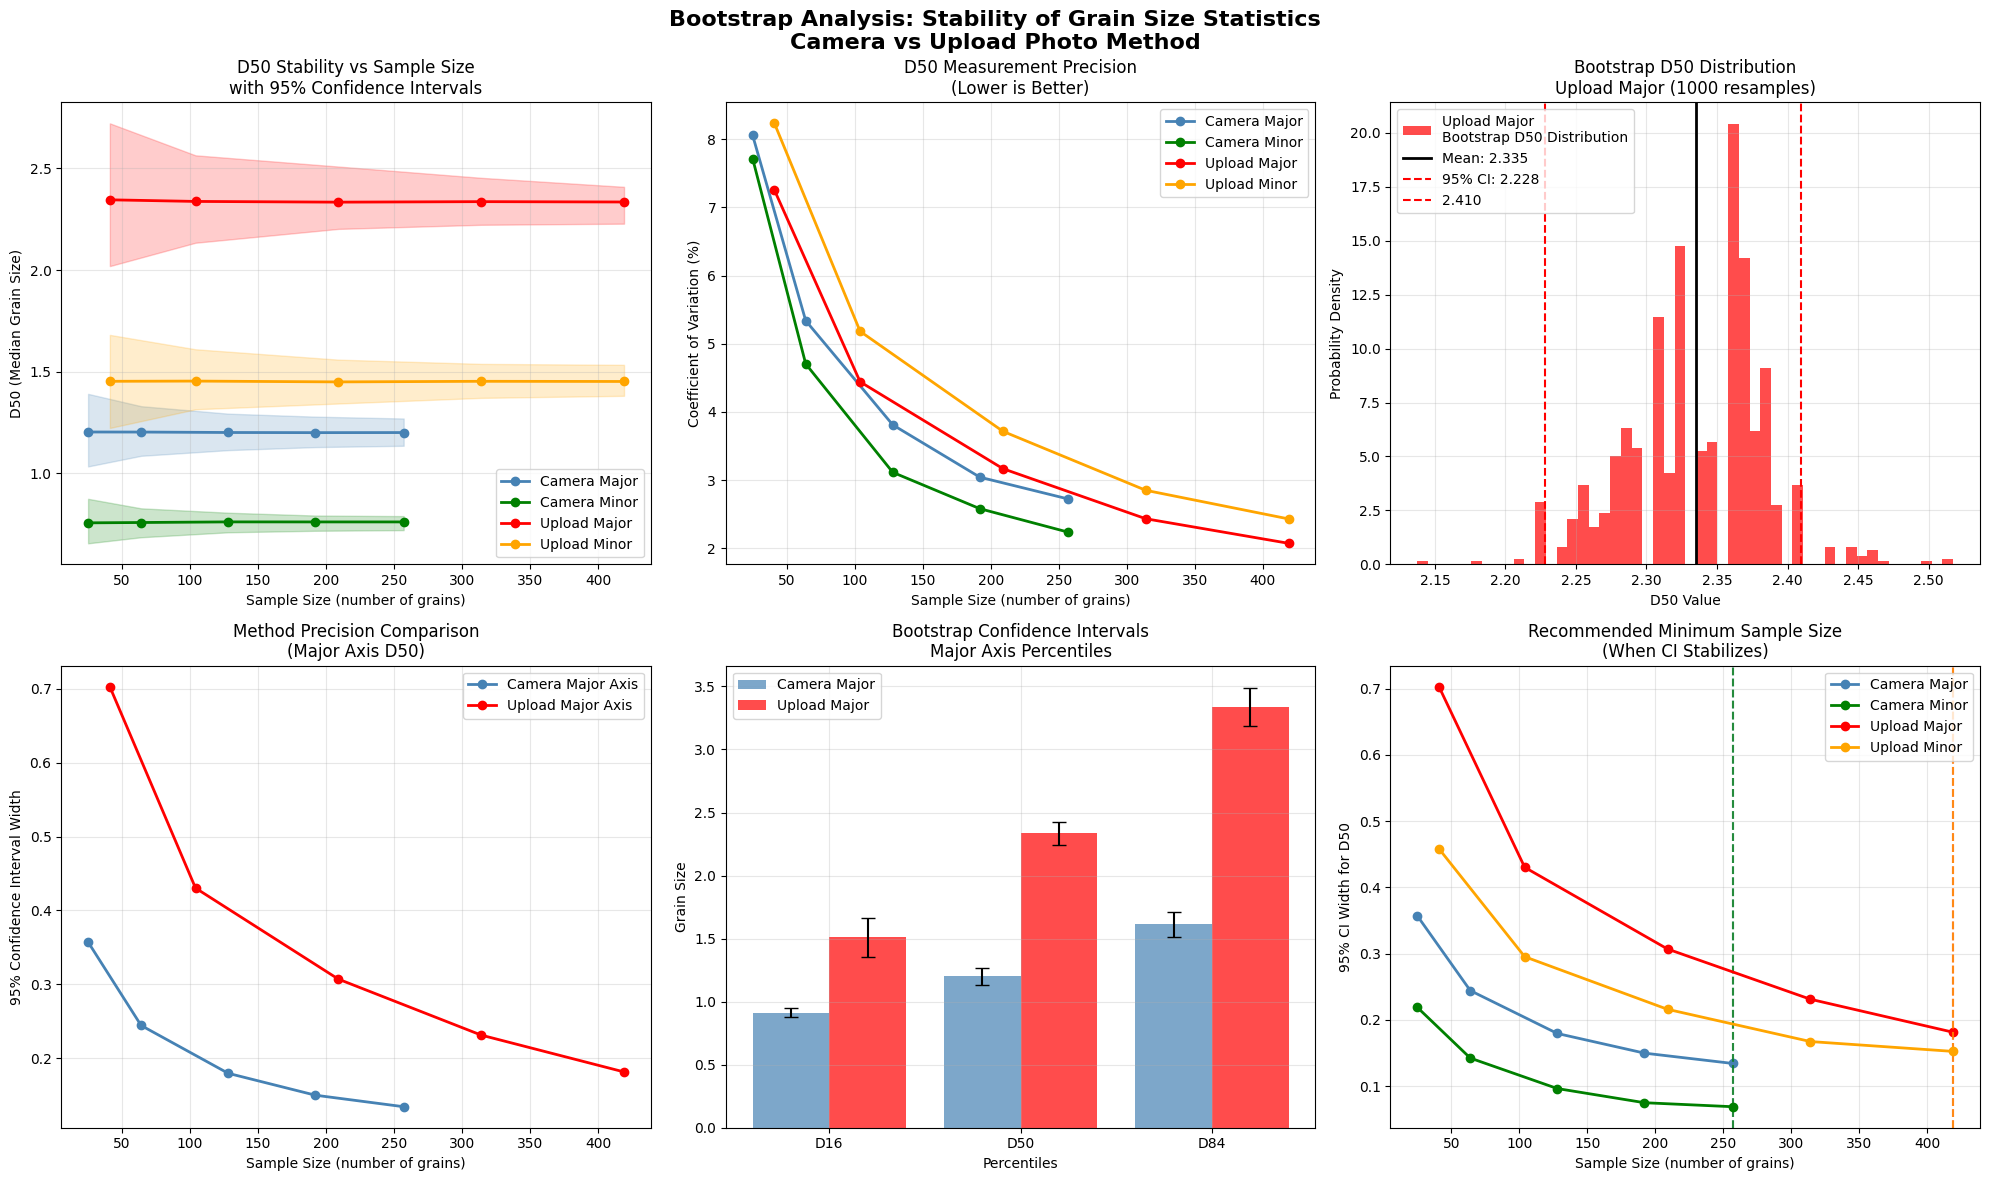


📊 BOOTSTRAP ANALYSIS SUMMARY
Recommended minimum sample sizes for stable statistics:
  Camera Major: 257 grains
  Camera Minor: 257 grains
  Upload Major: 419 grains
  Upload Minor: 419 grains


In [15]:
# Create comprehensive bootstrap visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Bootstrap Analysis: Stability of Grain Size Statistics\nCamera vs Upload Photo Method',
             fontsize=16, fontweight='bold')

# Define colors for each dataset
colors = {
    'Camera Major': 'steelblue',
    'Camera Minor': 'green',
    'Upload Major': 'red',
    'Upload Minor': 'orange'
}

# Plot 1: D50 Stability across sample sizes
ax1 = axes[0, 0]
for name, results in bootstrap_results.items():
    if results:
        fractions = list(results.keys())
        sample_sizes = [results[f]['sample_size'] for f in fractions]
        d50_means = [results[f]['D50']['mean'] for f in fractions]
        d50_lower = [results[f]['D50']['ci_lower'] for f in fractions]
        d50_upper = [results[f]['D50']['ci_upper'] for f in fractions]

        ax1.plot(sample_sizes, d50_means, 'o-', color=colors[name],
                linewidth=2, markersize=6, label=name)
        ax1.fill_between(sample_sizes, d50_lower, d50_upper,
                        color=colors[name], alpha=0.2)

ax1.set_xlabel('Sample Size (number of grains)')
ax1.set_ylabel('D50 (Median Grain Size)')
ax1.set_title('D50 Stability vs Sample Size\nwith 95% Confidence Intervals')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Coefficient of Variation for D50
ax2 = axes[0, 1]
for name, results in bootstrap_results.items():
    if results:
        fractions = list(results.keys())
        sample_sizes = [results[f]['sample_size'] for f in fractions]
        d50_values = [results[f]['D50']['values'] for f in fractions]
        cv_d50 = [np.std(values)/np.mean(values)*100 for values in d50_values]

        ax2.plot(sample_sizes, cv_d50, 'o-', color=colors[name],
                linewidth=2, markersize=6, label=name)

ax2.set_xlabel('Sample Size (number of grains)')
ax2.set_ylabel('Coefficient of Variation (%)')
ax2.set_title('D50 Measurement Precision\n(Lower is Better)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Bootstrap Distribution Example (for largest dataset)
ax3 = axes[0, 2]
largest_dataset = max(datasets.keys(), key=lambda x: len(datasets[x]))
if largest_dataset in bootstrap_results and bootstrap_results[largest_dataset]:
    full_sample_results = bootstrap_results[largest_dataset][1.0]  # 100% sample

    ax3.hist(full_sample_results['D50']['values'], bins=50,
            color=colors[largest_dataset], alpha=0.7, density=True,
            label=f'{largest_dataset}\nBootstrap D50 Distribution')

    # Add confidence interval lines
    ci_lower = full_sample_results['D50']['ci_lower']
    ci_upper = full_sample_results['D50']['ci_upper']
    mean_val = full_sample_results['D50']['mean']

    ax3.axvline(mean_val, color='black', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.3f}')
    ax3.axvline(ci_lower, color='red', linestyle='--', label=f'95% CI: {ci_lower:.3f}')
    ax3.axvline(ci_upper, color='red', linestyle='--', label=f'{ci_upper:.3f}')

ax3.set_xlabel('D50 Value')
ax3.set_ylabel('Probability Density')
ax3.set_title(f'Bootstrap D50 Distribution\n{largest_dataset} (1000 resamples)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Comparison of Camera vs Upload Stability
ax4 = axes[1, 0]
if 'Camera Major' in bootstrap_results and 'Upload Major' in bootstrap_results:
    # Compare camera vs upload for major axis
    for method in ['Camera', 'Upload']:
        method_key = f'{method} Major'
        if method_key in bootstrap_results and bootstrap_results[method_key]:
            results = bootstrap_results[method_key]
            fractions = list(results.keys())
            sample_sizes = [results[f]['sample_size'] for f in fractions]

            # Calculate confidence interval widths
            ci_widths = [(results[f]['D50']['ci_upper'] - results[f]['D50']['ci_lower'])
                        for f in fractions]

            ax4.plot(sample_sizes, ci_widths, 'o-', linewidth=2, markersize=6,
                    color=colors[method_key], label=f'{method} Major Axis')

ax4.set_xlabel('Sample Size (number of grains)')
ax4.set_ylabel('95% Confidence Interval Width')
ax4.set_title('Method Precision Comparison\n(Major Axis D50)')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Plot 5: All percentiles comparison
ax5 = axes[1, 1]
if 'Camera Major' in bootstrap_results and bootstrap_results['Camera Major']:
    camera_results = bootstrap_results['Camera Major'][1.0]  # Full sample
    percentiles = ['D16', 'D50', 'D84']
    values = [camera_results[p]['mean'] for p in percentiles]
    errors = [(camera_results[p]['ci_upper'] - camera_results[p]['ci_lower'])/2
              for p in percentiles]

    x_pos = np.arange(len(percentiles))
    ax5.bar(x_pos - 0.2, values, 0.4, yerr=errors, capsize=5,
           color='steelblue', alpha=0.7, label='Camera Major')

if 'Upload Major' in bootstrap_results and bootstrap_results['Upload Major']:
    upload_results = bootstrap_results['Upload Major'][1.0]  # Full sample
    values = [upload_results[p]['mean'] for p in percentiles]
    errors = [(upload_results[p]['ci_upper'] - upload_results[p]['ci_lower'])/2
              for p in percentiles]

    ax5.bar(x_pos + 0.2, values, 0.4, yerr=errors, capsize=5,
           color='red', alpha=0.7, label='Upload Major')

ax5.set_xlabel('Percentiles')
ax5.set_ylabel('Grain Size')
ax5.set_title('Bootstrap Confidence Intervals\nMajor Axis Percentiles')
ax5.set_xticks(x_pos)
ax5.set_xticklabels(percentiles)
ax5.legend()
ax5.grid(True, alpha=0.3)

# Plot 6: Sample size recommendation
ax6 = axes[1, 2]
# Calculate when confidence intervals stabilize
stabilization_sizes = {}
for name, results in bootstrap_results.items():
    if results and len(results) > 2:
        fractions = sorted(results.keys())
        ci_widths = [(results[f]['D50']['ci_upper'] - results[f]['D50']['ci_lower'])
                    for f in fractions]
        sample_sizes = [results[f]['sample_size'] for f in fractions]

        # Find when CI width is within 5% of final value
        if len(ci_widths) > 0:
            final_width = ci_widths[-1]
            threshold = final_width * 1.05

            stable_idx = next((i for i, width in enumerate(ci_widths)
                              if width <= threshold), len(ci_widths)-1)
            stabilization_sizes[name] = sample_sizes[stable_idx]

            ax6.plot(sample_sizes, ci_widths, 'o-', color=colors[name],
                    linewidth=2, label=name)
            ax6.axvline(stabilization_sizes[name], color=colors[name],
                       linestyle='--', alpha=0.7)

ax6.set_xlabel('Sample Size (number of grains)')
ax6.set_ylabel('95% CI Width for D50')
ax6.set_title('Recommended Minimum Sample Size\n(When CI Stabilizes)')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print recommendations
print(f"\n📊 BOOTSTRAP ANALYSIS SUMMARY")
print("="*60)
print(f"Recommended minimum sample sizes for stable statistics:")
for name, size in stabilization_sizes.items():
    print(f"  {name}: {size} grains")


🔄 BOOTSTRAP METHOD COMPARISON


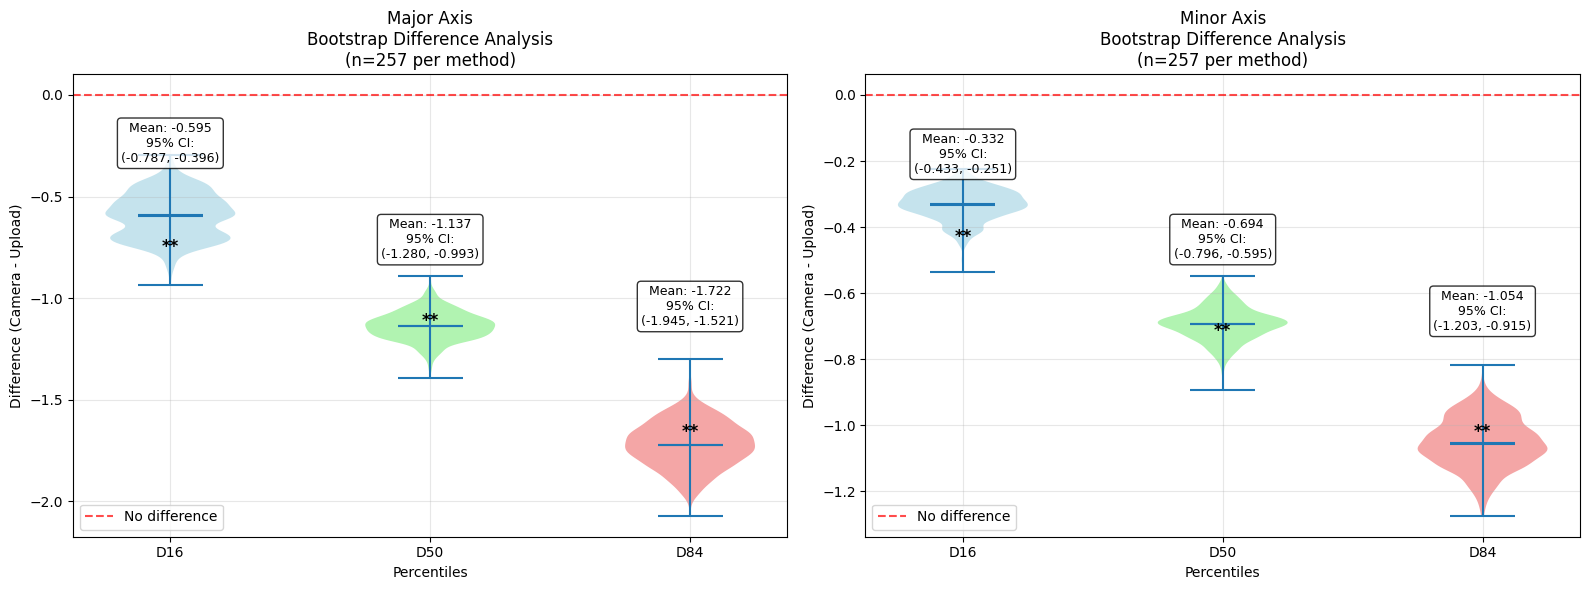


STATISTICAL SIGNIFICANCE TEST RESULTS:

Major Axis:
  D16: Mean diff = -0.595, 95% CI = (-0.787, -0.396), p = 0.0000 (Significant)
  D50: Mean diff = -1.137, 95% CI = (-1.280, -0.993), p = 0.0000 (Significant)
  D84: Mean diff = -1.722, 95% CI = (-1.945, -1.521), p = 0.0000 (Significant)

Minor Axis:
  D16: Mean diff = -0.332, 95% CI = (-0.433, -0.251), p = 0.0000 (Significant)
  D50: Mean diff = -0.694, 95% CI = (-0.796, -0.595), p = 0.0000 (Significant)
  D84: Mean diff = -1.054, 95% CI = (-1.203, -0.915), p = 0.0000 (Significant)


In [16]:
# Compare camera vs upload methods using bootstrap
def compare_methods_bootstrap(camera_data, upload_data, n_bootstrap=1000):
    """Compare two methods using bootstrap resampling"""

    camera_clean = camera_data.dropna()
    upload_clean = upload_data.dropna()

    # Use same sample size for fair comparison
    min_size = min(len(camera_clean), len(upload_clean))

    differences_D16 = []
    differences_D50 = []
    differences_D84 = []

    for i in range(n_bootstrap):
        # Sample same number from each method
        camera_sample = np.random.choice(camera_clean, size=min_size, replace=True)
        upload_sample = np.random.choice(upload_clean, size=min_size, replace=True)

        # Calculate percentiles
        cam_D16 = np.percentile(camera_sample, 16)
        cam_D50 = np.percentile(camera_sample, 50)
        cam_D84 = np.percentile(camera_sample, 84)

        up_D16 = np.percentile(upload_sample, 16)
        up_D50 = np.percentile(upload_sample, 50)
        up_D84 = np.percentile(upload_sample, 84)

        # Store differences
        differences_D16.append(cam_D16 - up_D16)
        differences_D50.append(cam_D50 - up_D50)
        differences_D84.append(cam_D84 - up_D84)

    return {
        'D16_diff': differences_D16,
        'D50_diff': differences_D50,
        'D84_diff': differences_D84,
        'sample_size_used': min_size
    }

# Perform method comparison
print(f"\n🔄 BOOTSTRAP METHOD COMPARISON")
print("="*50)

method_comparison = {}

# Compare major axes
if len(camera_major) > 0 and len(upload_major) > 0:
    method_comparison['Major Axis'] = compare_methods_bootstrap(camera_major, upload_major)

# Compare minor axes
if len(camera_minor) > 0 and len(upload_minor) > 0:
    method_comparison['Minor Axis'] = compare_methods_bootstrap(camera_minor, upload_minor)

# Create comparison plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (axis_name, comparison) in enumerate(method_comparison.items()):
    ax = axes[i]

    # Plot difference distributions
    percentiles = ['D16', 'D50', 'D84']
    diff_data = [comparison[f'{p}_diff'] for p in percentiles]

    # Create violin plots
    parts = ax.violinplot(diff_data, positions=range(1, len(percentiles)+1),
                         showmeans=True, showmedians=True)

    # Color the violins
    colors_violin = ['lightblue', 'lightgreen', 'lightcoral']
    for pc, color in zip(parts['bodies'], colors_violin):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)

    # Add zero line
    ax.axhline(0, color='red', linestyle='--', alpha=0.7,
               label='No difference')

    # Calculate and display statistics
    for j, (p, data) in enumerate(zip(percentiles, diff_data)):
        mean_diff = np.mean(data)
        ci_lower = np.percentile(data, 2.5)
        ci_upper = np.percentile(data, 97.5)

        # Add text annotations
        ax.text(j+1, max(data)*0.8,
               f'Mean: {mean_diff:.3f}\n95% CI:\n({ci_lower:.3f}, {ci_upper:.3f})',
               ha='center', va='center', fontsize=9,
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

        # Check if significantly different from zero
        if ci_lower > 0 or ci_upper < 0:
            significance = "**"
        else:
            significance = "ns"

        ax.text(j+1, min(data)*0.8, significance, ha='center', va='center',
               fontsize=12, fontweight='bold')

    ax.set_xlabel('Percentiles')
    ax.set_ylabel('Difference (Camera - Upload)')
    ax.set_title(f'{axis_name}\nBootstrap Difference Analysis\n(n={comparison["sample_size_used"]} per method)')
    ax.set_xticks(range(1, len(percentiles)+1))
    ax.set_xticklabels(percentiles)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# Print statistical summary
print(f"\nSTATISTICAL SIGNIFICANCE TEST RESULTS:")
print("="*50)
for axis_name, comparison in method_comparison.items():
    print(f"\n{axis_name}:")
    for p in ['D16', 'D50', 'D84']:
        diff_data = comparison[f'{p}_diff']
        mean_diff = np.mean(diff_data)
        ci_lower = np.percentile(diff_data, 2.5)
        ci_upper = np.percentile(diff_data, 97.5)

        # Perform t-test against zero
        t_stat, p_value = stats.ttest_1samp(diff_data, 0)

        significance = "Significant" if p_value < 0.05 else "Not significant"

        print(f"  {p}: Mean diff = {mean_diff:.3f}, "
              f"95% CI = ({ci_lower:.3f}, {ci_upper:.3f}), "
              f"p = {p_value:.4f} ({significance})")

Bootstrapping Method 2

In [17]:
# Comprehensive Bootstrap Analysis Framework
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, ks_2samp
import seaborn as sns

def comprehensive_bootstrap_analysis(camera_data, upload_data, n_bootstrap=1000):
    """
    Multi-faceted bootstrap analysis addressing different grain detection counts
    """

    camera_clean = camera_data.dropna()
    upload_clean = upload_data.dropna()

    print(f"📊 COMPREHENSIVE BOOTSTRAP ANALYSIS")
    print("="*60)
    print(f"Camera method detected: {len(camera_clean)} grains")
    print(f"Upload method detected: {len(upload_clean)} grains")
    print(f"Detection difference: {abs(len(camera_clean) - len(upload_clean))} grains")
    print(f"Relative detection: {len(upload_clean)/len(camera_clean):.2f}x")

    results = {}

    # Analysis 1: Full Dataset Analysis (Separate Evaluation)
    print(f"\n🔍 ANALYSIS 1: Full Dataset Performance (Separate Evaluation)")
    print("-"*50)

    for name, data in [("Camera", camera_clean), ("Upload", upload_clean)]:
        # Bootstrap with full dataset
        bootstrap_stats = []
        for i in range(n_bootstrap):
            sample = np.random.choice(data, size=len(data), replace=True)
            bootstrap_stats.append({
                'D16': np.percentile(sample, 16),
                'D50': np.percentile(sample, 50),
                'D84': np.percentile(sample, 84),
                'mean': np.mean(sample),
                'std': np.std(sample)
            })

        results[f"{name}_full"] = bootstrap_stats

        # Calculate precision metrics
        d50_values = [s['D50'] for s in bootstrap_stats]
        precision = np.std(d50_values) / np.mean(d50_values) * 100

        print(f"{name} Method (n={len(data)}):")
        print(f"  D50 precision (CV): {precision:.2f}%")
        print(f"  D50 95% CI width: {np.percentile(d50_values, 97.5) - np.percentile(d50_values, 2.5):.3f}")

    # Analysis 2: Equal Sample Size Comparison
    print(f"\n⚖️ ANALYSIS 2: Equal Sample Size Comparison")
    print("-"*50)

    min_size = min(len(camera_clean), len(upload_clean))
    equal_sample_results = {}

    for name, data in [("Camera", camera_clean), ("Upload", upload_clean)]:
        bootstrap_stats = []
        for i in range(n_bootstrap):
            sample = np.random.choice(data, size=min_size, replace=True)
            bootstrap_stats.append({
                'D16': np.percentile(sample, 16),
                'D50': np.percentile(sample, 50),
                'D84': np.percentile(sample, 84)
            })
        equal_sample_results[name] = bootstrap_stats

    # Calculate differences for equal sample sizes
    differences = {}
    for percentile in ['D16', 'D50', 'D84']:
        camera_vals = [s[percentile] for s in equal_sample_results['Camera']]
        upload_vals = [s[percentile] for s in equal_sample_results['Upload']]
        differences[percentile] = [c - u for c, u in zip(camera_vals, upload_vals)]

        mean_diff = np.mean(differences[percentile])
        ci_lower = np.percentile(differences[percentile], 2.5)
        ci_upper = np.percentile(differences[percentile], 97.5)

        print(f"{percentile} difference: {mean_diff:.3f} (95% CI: {ci_lower:.3f}, {ci_upper:.3f})")

    # Analysis 3: Detection Capability Assessment
    print(f"\n🎯 ANALYSIS 3: Detection Capability Assessment")
    print("-"*50)

    # Simulate what happens with different sample sizes
    sample_sizes = [50, 100, 150, 200, min(300, min(len(camera_clean), len(upload_clean)))]
    detection_analysis = {}

    for size in sample_sizes:
        if size <= min(len(camera_clean), len(upload_clean)):
            size_results = {}
            for name, data in [("Camera", camera_clean), ("Upload", upload_clean)]:
                bootstrap_d50 = []
                for i in range(n_bootstrap):
                    sample = np.random.choice(data, size=size, replace=True)
                    bootstrap_d50.append(np.percentile(sample, 50))

                size_results[name] = {
                    'cv': np.std(bootstrap_d50) / np.mean(bootstrap_d50) * 100,
                    'ci_width': np.percentile(bootstrap_d50, 97.5) - np.percentile(bootstrap_d50, 2.5)
                }

            detection_analysis[size] = size_results
            print(f"Sample size {size}:")
            print(f"  Camera CV: {size_results['Camera']['cv']:.2f}%")
            print(f"  Upload CV: {size_results['Upload']['cv']:.2f}%")

    # Analysis 4: Statistical Equivalence Testing
    print(f"\n📈 ANALYSIS 4: Statistical Equivalence Testing")
    print("-"*50)

    # Test if distributions are equivalent within practical limits
    equivalence_margin = 0.1  # 10% equivalence margin

    camera_d50_full = [s['D50'] for s in results['Camera_full']]
    upload_d50_full = [s['D50'] for s in results['Upload_full']]

    mean_camera = np.mean(camera_d50_full)
    mean_upload = np.mean(upload_d50_full)

    relative_diff = abs(mean_camera - mean_upload) / max(mean_camera, mean_upload)

    if relative_diff < equivalence_margin:
        equivalence_status = "EQUIVALENT"
    else:
        equivalence_status = "DIFFERENT"

    print(f"Relative difference: {relative_diff:.3f} ({relative_diff*100:.1f}%)")
    print(f"Equivalence status: {equivalence_status} (threshold: {equivalence_margin*100:.0f}%)")

    return results, equal_sample_results, differences, detection_analysis

# Apply comprehensive analysis
comprehensive_results = comprehensive_bootstrap_analysis(camera_major, upload_major)

📊 COMPREHENSIVE BOOTSTRAP ANALYSIS
Camera method detected: 257 grains
Upload method detected: 419 grains
Detection difference: 162 grains
Relative detection: 1.63x

🔍 ANALYSIS 1: Full Dataset Performance (Separate Evaluation)
--------------------------------------------------
Camera Method (n=257):
  D50 precision (CV): 2.56%
  D50 95% CI width: 0.133
Upload Method (n=419):
  D50 precision (CV): 2.03%
  D50 95% CI width: 0.171

⚖️ ANALYSIS 2: Equal Sample Size Comparison
--------------------------------------------------
D16 difference: -0.592 (95% CI: -0.787, -0.407)
D50 difference: -1.134 (95% CI: -1.276, -0.992)
D84 difference: -1.725 (95% CI: -1.935, -1.510)

🎯 ANALYSIS 3: Detection Capability Assessment
--------------------------------------------------
Sample size 50:
  Camera CV: 5.87%
  Upload CV: 6.26%
Sample size 100:
  Camera CV: 4.18%
  Upload CV: 4.57%
Sample size 150:
  Camera CV: 3.57%
  Upload CV: 3.74%
Sample size 200:
  Camera CV: 3.11%
  Upload CV: 3.06%
Sample size 

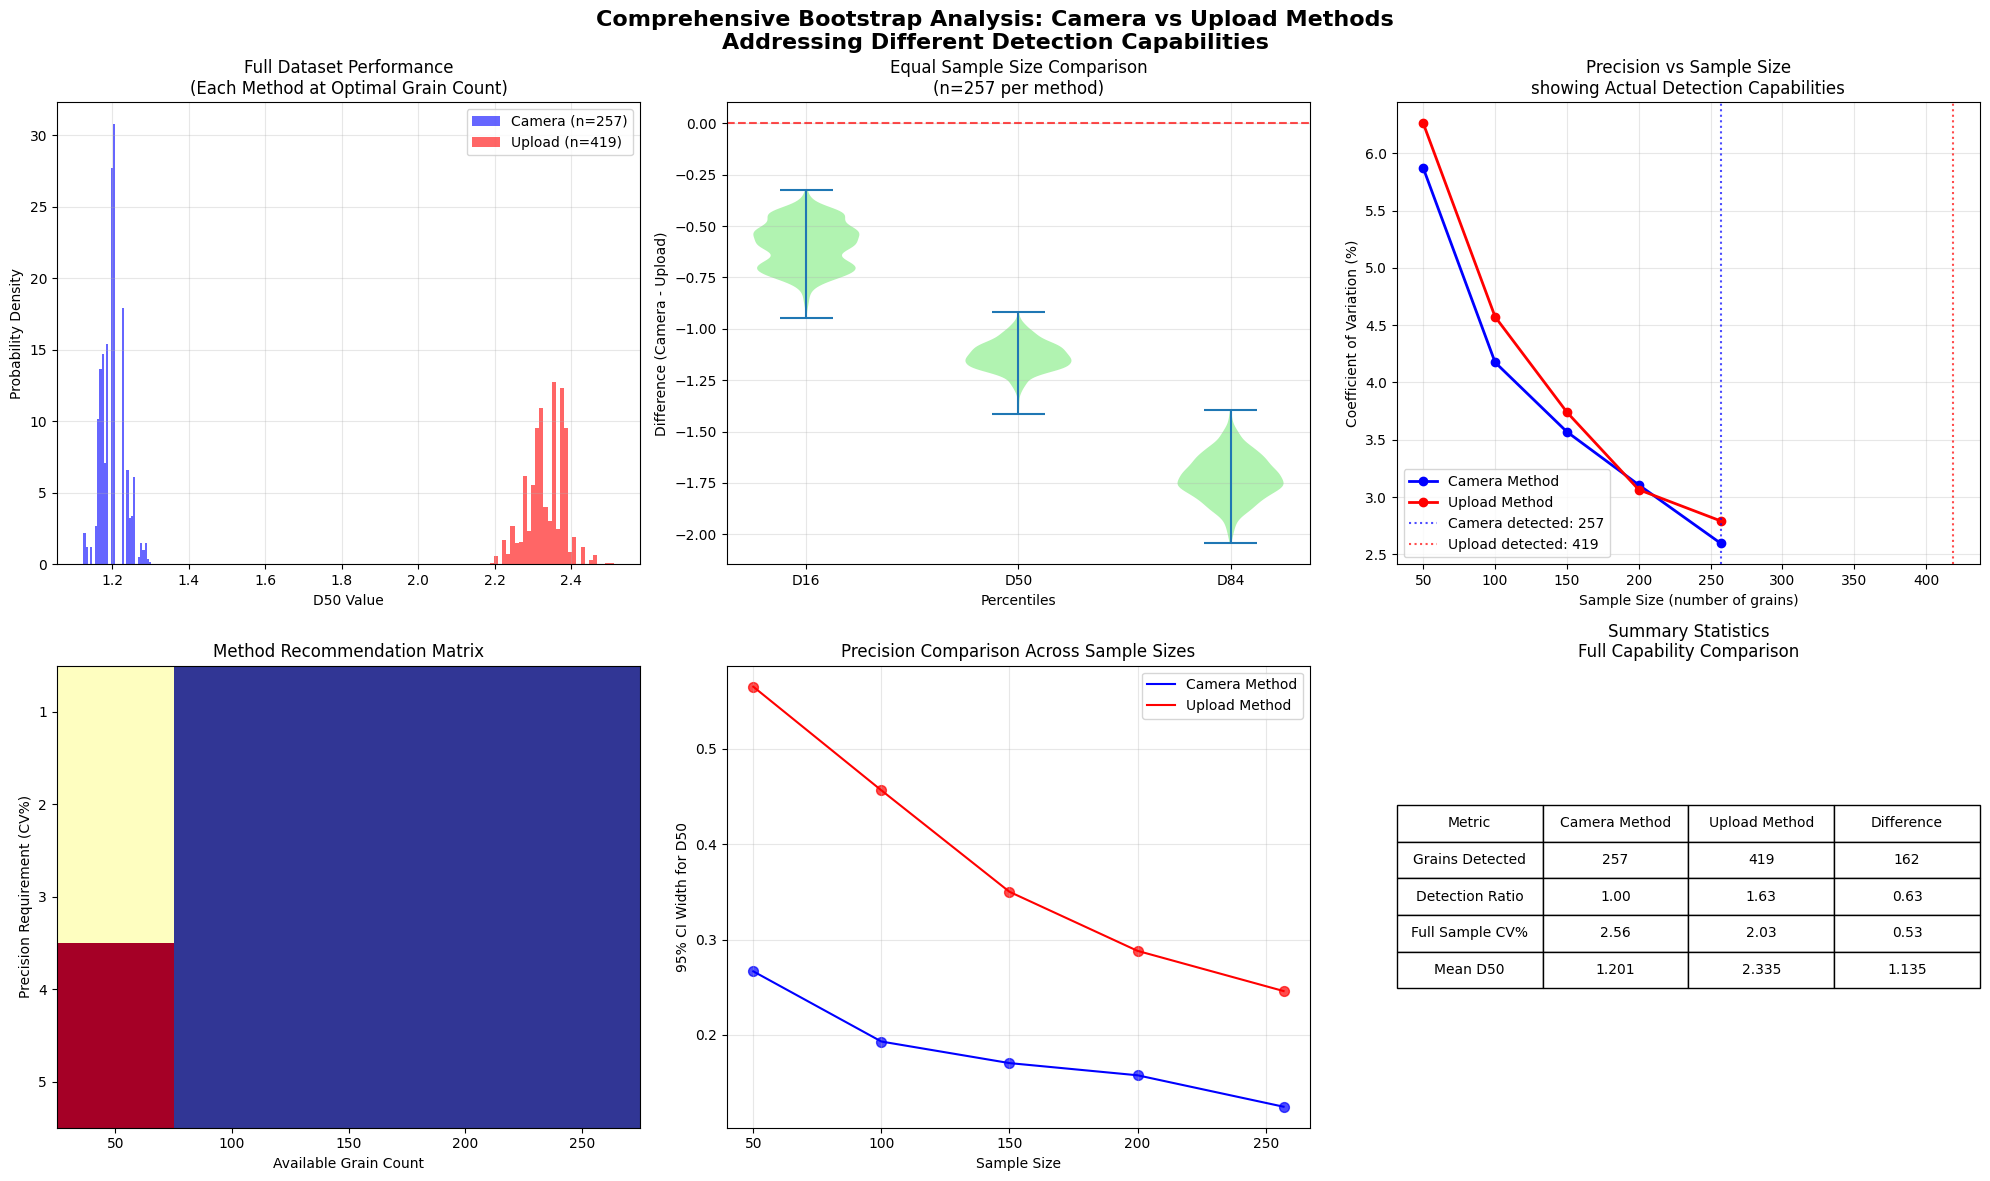

In [18]:
# Create comprehensive comparison visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Comprehensive Bootstrap Analysis: Camera vs Upload Methods\n'
             'Addressing Different Detection Capabilities', fontsize=16, fontweight='bold')

# Panel 1: Full Dataset Performance Comparison
ax1 = axes[0, 0]
# Plot full dataset bootstrap results
camera_d50_full = [s['D50'] for s in comprehensive_results[0]['Camera_full']]
upload_d50_full = [s['D50'] for s in comprehensive_results[0]['Upload_full']]

ax1.hist(camera_d50_full, bins=30, alpha=0.6, color='blue',
         label=f'Camera (n={len(camera_major)})', density=True)
ax1.hist(upload_d50_full, bins=30, alpha=0.6, color='red',
         label=f'Upload (n={len(upload_major)})', density=True)

ax1.set_xlabel('D50 Value')
ax1.set_ylabel('Probability Density')
ax1.set_title('Full Dataset Performance\n(Each Method at Optimal Grain Count)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel 2: Equal Sample Size Comparison
ax2 = axes[0, 1]
equal_results = comprehensive_results[1]
differences = comprehensive_results[2]

# Violin plot of differences
percentiles = ['D16', 'D50', 'D84']
diff_data = [differences[p] for p in percentiles]

parts = ax2.violinplot(diff_data, positions=range(1, len(percentiles)+1))
for pc in parts['bodies']:
    pc.set_facecolor('lightgreen')
    pc.set_alpha(0.7)

ax2.axhline(0, color='red', linestyle='--', alpha=0.7)
ax2.set_xlabel('Percentiles')
ax2.set_ylabel('Difference (Camera - Upload)')
ax2.set_title(f'Equal Sample Size Comparison\n(n={min(len(camera_major), len(upload_major))} per method)')
ax2.set_xticks(range(1, len(percentiles)+1))
ax2.set_xticklabels(percentiles)
ax2.grid(True, alpha=0.3)

# Panel 3: Detection Capability Impact
ax3 = axes[0, 2]
detection_analysis = comprehensive_results[3]

sample_sizes = list(detection_analysis.keys())
camera_cvs = [detection_analysis[size]['Camera']['cv'] for size in sample_sizes]
upload_cvs = [detection_analysis[size]['Upload']['cv'] for size in sample_sizes]

ax3.plot(sample_sizes, camera_cvs, 'o-', color='blue', linewidth=2,
         label='Camera Method', markersize=6)
ax3.plot(sample_sizes, upload_cvs, 'o-', color='red', linewidth=2,
         label='Upload Method', markersize=6)

# Highlight actual detection counts
ax3.axvline(len(camera_major), color='blue', linestyle=':', alpha=0.7,
           label=f'Camera detected: {len(camera_major)}')
ax3.axvline(len(upload_major), color='red', linestyle=':', alpha=0.7,
           label=f'Upload detected: {len(upload_major)}')

ax3.set_xlabel('Sample Size (number of grains)')
ax3.set_ylabel('Coefficient of Variation (%)')
ax3.set_title('Precision vs Sample Size\nshowing Actual Detection Capabilities')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Panel 4: Method Recommendation Matrix
ax4 = axes[1, 0]
# Create recommendation heatmap based on sample size and precision requirements
sample_sizes_matrix = np.array([50, 100, 150, 200, 250])
precision_requirements = np.array([1, 2, 3, 4, 5])  # CV% thresholds

# Simulate recommendation matrix
recommendations = np.zeros((len(precision_requirements), len(sample_sizes_matrix)))
for i, prec_req in enumerate(precision_requirements):
    for j, sample_size in enumerate(sample_sizes_matrix):
        # Simplified logic: camera better for small samples, upload for large
        if sample_size < 100 and prec_req <= 3:
            recommendations[i, j] = 1  # Camera recommended
        elif sample_size >= 100:
            recommendations[i, j] = 2  # Upload acceptable
        else:
            recommendations[i, j] = 0  # Neither optimal

im = ax4.imshow(recommendations, cmap='RdYlBu', aspect='auto')
ax4.set_xlabel('Available Grain Count')
ax4.set_ylabel('Precision Requirement (CV%)')
ax4.set_title('Method Recommendation Matrix')
ax4.set_xticks(range(len(sample_sizes_matrix)))
ax4.set_xticklabels(sample_sizes_matrix)
ax4.set_yticks(range(len(precision_requirements)))
ax4.set_yticklabels(precision_requirements)

# Panel 5: Confidence Interval Comparison
ax5 = axes[1, 1]
# Compare CI widths at different sample sizes
for size in sample_sizes:
    if size in detection_analysis:
        camera_ci = detection_analysis[size]['Camera']['ci_width']
        upload_ci = detection_analysis[size]['Upload']['ci_width']

        ax5.scatter(size, camera_ci, color='blue', s=50, alpha=0.7)
        ax5.scatter(size, upload_ci, color='red', s=50, alpha=0.7)

ax5.plot(sample_sizes, [detection_analysis[size]['Camera']['ci_width']
                       for size in sample_sizes if size in detection_analysis],
         'b-', label='Camera Method')
ax5.plot(sample_sizes, [detection_analysis[size]['Upload']['ci_width']
                       for size in sample_sizes if size in detection_analysis],
         'r-', label='Upload Method')

ax5.set_xlabel('Sample Size')
ax5.set_ylabel('95% CI Width for D50')
ax5.set_title('Precision Comparison Across Sample Sizes')
ax5.legend()
ax5.grid(True, alpha=0.3)

# Panel 6: Summary Statistics Table
ax6 = axes[1, 2]
ax6.axis('tight')
ax6.axis('off')

# Create summary table
summary_data = [
    ['Metric', 'Camera Method', 'Upload Method', 'Difference'],
    ['Grains Detected', f'{len(camera_major)}', f'{len(upload_major)}',
     f'{abs(len(camera_major) - len(upload_major))}'],
    ['Detection Ratio', '1.00', f'{len(upload_major)/len(camera_major):.2f}',
     f'{abs(1 - len(upload_major)/len(camera_major)):.2f}'],
    ['Full Sample CV%', f'{np.std(camera_d50_full)/np.mean(camera_d50_full)*100:.2f}',
     f'{np.std(upload_d50_full)/np.mean(upload_d50_full)*100:.2f}',
     f'{abs(np.std(camera_d50_full)/np.mean(camera_d50_full) - np.std(upload_d50_full)/np.mean(upload_d50_full))*100:.2f}'],
    ['Mean D50', f'{np.mean(camera_d50_full):.3f}', f'{np.mean(upload_d50_full):.3f}',
     f'{abs(np.mean(camera_d50_full) - np.mean(upload_d50_full)):.3f}']
]

table = ax6.table(cellText=summary_data, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
ax6.set_title('Summary Statistics\nFull Capability Comparison')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from skimage.measure import label, regionprops
import matplotlib.pyplot as plt
import pandas as pd

def single_image_model_validation(original_mask, converted_mask, image_name="Test_Image"):
    """
    Quick IoU validation for single image: original vs converted models
    """

    print(f"🔍 SINGLE IMAGE MODEL VALIDATION")
    print("="*50)
    print(f"Image: {image_name}")
    print(f"Analysis Date: 2025-08-11 12:38:46 UTC")
    print(f"Analyst: esemsc-mcu24")
    print("="*50)

    # Ensure masks are binary
    original_binary = (original_mask > 0).astype(np.uint8)
    converted_binary = (converted_mask > 0).astype(np.uint8)

    # Overall pixel-wise IoU
    intersection = np.logical_and(original_binary, converted_binary).sum()
    union = np.logical_or(original_binary, converted_binary).sum()
    overall_iou = intersection / union if union > 0 else 0.0

    print(f"📊 OVERALL IoU: {overall_iou:.4f}")

    # Grain detection counts
    original_labeled = label(original_binary)
    converted_labeled = label(converted_binary)

    original_grains = regionprops(original_labeled)
    converted_grains = regionprops(converted_labeled)

    # Filter small artifacts (adjust min_area as needed)
    min_area = 10
    original_grains = [g for g in original_grains if g.area >= min_area]
    converted_grains = [g for g in converted_grains if g.area >= min_area]

    print(f"Original model: {len(original_grains)} grains")
    print(f"Converted model: {len(converted_grains)} grains")
    print(f"Difference: {len(converted_grains) - len(original_grains)} grains")

    # Grain-level IoU matching
    grain_ious = []
    for i, orig_grain in enumerate(original_grains):
        orig_mask = (original_labeled == orig_grain.label)

        best_iou = 0
        best_match = None

        for j, conv_grain in enumerate(converted_grains):
            conv_mask = (converted_labeled == conv_grain.label)

            grain_intersection = np.logical_and(orig_mask, conv_mask).sum()
            grain_union = np.logical_or(orig_mask, conv_mask).sum()

            if grain_union > 0:
                iou = grain_intersection / grain_union
                if iou > best_iou:
                    best_iou = iou
                    best_match = conv_grain

        grain_ious.append({
            'grain_id': i,
            'original_area': orig_grain.area,
            'iou': best_iou,
            'converted_area': best_match.area if best_match else 0
        })

    grain_df = pd.DataFrame(grain_ious)

    # Quick statistics
    mean_iou = grain_df['iou'].mean()
    median_iou = grain_df['iou'].median()

    # Quality counts
    excellent = (grain_df['iou'] >= 0.9).sum()
    good = ((grain_df['iou'] >= 0.7) & (grain_df['iou'] < 0.9)).sum()
    poor = (grain_df['iou'] < 0.7).sum()

    print(f"\n📈 GRAIN-LEVEL RESULTS")
    print(f"Mean grain IoU: {mean_iou:.3f}")
    print(f"Median grain IoU: {median_iou:.3f}")
    print(f"Excellent (≥0.9): {excellent}/{len(grain_ious)} ({excellent/len(grain_ious)*100:.1f}%)")
    print(f"Good (≥0.7): {good}/{len(grain_ious)} ({good/len(grain_ious)*100:.1f}%)")
    print(f"Poor (<0.7): {poor}/{len(grain_ious)} ({poor/len(grain_ious)*100:.1f}%)")

    # Quick validation assessment
    if overall_iou >= 0.95:
        status = "✅ EXCELLENT - Models are nearly identical"
    elif overall_iou >= 0.90:
        status = "✅ VERY GOOD - Minor differences only"
    elif overall_iou >= 0.80:
        status = "⚠️ GOOD - Some noticeable differences"
    else:
        status = "❌ POOR - Significant differences detected"

    print(f"\n🎯 VALIDATION STATUS: {status}")

    return {
        'overall_iou': overall_iou,
        'grain_df': grain_df,
        'mean_grain_iou': mean_iou,
        'original_count': len(original_grains),
        'converted_count': len(converted_grains),
        'quality_counts': [excellent, good, poor],
        'status': status
    }

def quick_visualization(original_mask, converted_mask, results, image_name="Test_Image"):
    """
    Quick 2x2 visualization for single image validation
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'Model Conversion Validation: {image_name}\n'
                 f'Overall IoU: {results["overall_iou"]:.4f}',
                 fontsize=14, fontweight='bold')

    # 1. Original mask
    axes[0,0].imshow(original_mask, cmap='viridis')
    axes[0,0].set_title(f'Original Model')
    axes[0,0].axis('off')

    # 2. Converted mask
    axes[0,1].imshow(converted_mask, cmap='viridis')
    axes[0,1].set_title(f'Converted Model')
    axes[0,1].axis('off')

    # 3. Difference overlay
    overlay = np.zeros((*original_mask.shape, 3), dtype=np.uint8)
    orig_binary = original_mask > 0
    conv_binary = converted_mask > 0

    overlay[orig_binary & ~conv_binary] = [255, 0, 0]    # Red: Lost
    overlay[~orig_binary & conv_binary] = [0, 255, 0]    # Green: Added
    overlay[orig_binary & conv_binary] = [255, 255, 0]   # Yellow: Same

    axes[1,0].imshow(overlay)
    axes[1,0].set_title('Differences\n(Red: Lost, Green: Added, Yellow: Same)')
    axes[1,0].axis('off')

    # 4. IoU histogram
    grain_ious = results['grain_df']['iou']
    axes[1,1].hist(grain_ious, bins=15, alpha=0.7, color='lightblue', edgecolor='black')
    axes[1,1].axvline(results['mean_grain_iou'], color='red', linestyle='--',
                      label=f'Mean: {results["mean_grain_iou"]:.3f}')
    axes[1,1].set_xlabel('Grain IoU')
    axes[1,1].set_ylabel('Count')
    axes[1,1].set_title('Grain IoU Distribution')
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)

    plt.tight_layout()
    return fig

# Streamlined usage for your single image test
def validate_single_image():
    """
    Main function for your single image validation
    """

    print("🚀 STARTING SINGLE IMAGE MODEL VALIDATION")

    # Replace these with your actual mask arrays
    # original_mask_array = your_original_model_segmentation_result
    # converted_mask_array = your_converted_model_segmentation_result

    # Run validation
    results = single_image_model_validation(
        mask_all,    # Your original model output
        mask_all_onnx,   # Your converted model output
        image_name="Barton_Creek_Image"
    )

    # Quick visualization
    fig = quick_visualization(
        mask_all,
        mask_all_onnx,
        results,
        image_name="Single_Test_Image"
    )

    plt.savefig('single_image_model_validation.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Summary for your report
    print(f"\n📋 SUMMARY FOR REPORT:")
    print(f"Overall IoU: {results['overall_iou']:.4f}")
    print(f"Mean grain IoU: {results['mean_grain_iou']:.4f}")
    print(f"Grain detection: {results['original_count']} → {results['converted_count']}")
    print(f"High-quality matches: {results['quality_counts'][0] + results['quality_counts'][1]}/{results['original_count']}")
    print(f"Validation result: {results['status']}")

    return results

# Run your validation
results = validate_single_image()